In [1]:
import ROOT, math, numpy as np

Welcome to JupyROOT 6.26/06


In [2]:
from pyunfold import iterative_unfold
from pyunfold.callbacks import Logger
import pyunfold

In [3]:
import numpy as np
np.random.seed(2)
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [4]:
sns.set_context(context='poster')
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['lines.markeredgewidth'] = 2

In [5]:
File = ROOT.TFile("LEP1MC1994_recons_aftercut-001.root")
#no detector simulation for matchbox
File.ls()

TFile**		LEP1MC1994_recons_aftercut-001.root	
 TFile*		LEP1MC1994_recons_aftercut-001.root	
  KEY: TTree	t;1	t
  KEY: TTree	akR4ESchemeJetTree;1	akR4ESchemeJetTree
  KEY: TTree	akR4WTAmodpSchemeJetTree;1	akR4WTAmodpSchemeJetTree
  KEY: TTree	akR8ESchemeJetTree;1	akR8ESchemeJetTree
  KEY: TTree	akR8WTAmodpSchemeJetTree;1	akR8WTAmodpSchemeJetTree
  KEY: TTree	BoostedWTAR8Evt;1	BoostedWTAR8Evt
  KEY: TTree	ktN2ESchemeJetTree;1	ktN2ESchemeJetTree
  KEY: TTree	ktN2WTAmodpSchemeJetTree;1	ktN2WTAmodpSchemeJetTree
  KEY: TTree	BoostedWTAktN2Evt;1	BoostedWTAktN2Evt
  KEY: TTree	ktN3ESchemeJetTree;1	ktN3ESchemeJetTree
  KEY: TTree	ktN3WTAmodpSchemeJetTree;1	ktN3WTAmodpSchemeJetTree
  KEY: TTree	tgen;1	tgen
  KEY: TTree	tgenBefore;1	tgenBefore
  KEY: TTree	akR4ESchemeGenJetTree;1	akR4ESchemeGenJetTree
  KEY: TTree	akR4ESchemeGenJetBeforeTree;1	akR4ESchemeGenJetBeforeTree
  KEY: TTree	akR4WTAmodpSchemeGenJetTree;1	akR4WTAmodpSchemeGenJetTree
  KEY: TTree	akR4WTAmodpSchemeGenJetBeforeTree;1	akR4WTA

In [7]:
# Part 1 Simulation comparison 

In [5]:
def jetshape(inputfilename, outputfilename, JetTreename, particletreename):
    File = ROOT.TFile("LEP1Data1994P1_recons_aftercut-MERGED.root")
    outFile = ROOT.TFile(outputfilename, "recreate")
    Hist12 = ROOT.TH1D("HIST12", "Total Energy vs. Distance", 80, 0, 2)
    Counter = 0
    TreeGen = File.Get(JetTreename)
    TreeParticle = File.Get(particletreename)
    TotalNumberOfCollisions = TreeParticle.GetEntries("nParticle")
    TargetNumberOfCollisions = TotalNumberOfCollisions * 0.01
    CurrentlyProcessed = 0
    for EventGen, ParticleGen in zip(TreeGen, TreeParticle):
         CurrentlyProcessed = CurrentlyProcessed + 1
         if CurrentlyProcessed > TargetNumberOfCollisions:
             break
         GenPX = [EventGen.jtpt[i] * math.cos(EventGen.jteta[i]) for i in range(EventGen.nref)]
         GenPY = [EventGen.jtpt[i] * math.sin(EventGen.jteta[i]) for i in range(EventGen.nref)]
         GenPZ = [EventGen.jtpt[i] * math.sinh(EventGen.jteta[i]) for i in range(EventGen.nref)]
         GenP =  [EventGen.jtpt[i] * math.cosh(EventGen.jteta[i]) for i in range(EventGen.nref)]
         GenE = [math.sqrt(EventGen.jtm[i]**2 + GenP[i]**2) for i in range(EventGen.nref)]
        #E1
         PGPX = [ParticleGen.pt[i] * math.cos(ParticleGen.eta[i]) for i in range(ParticleGen.nParticle)]
         PGPY = [ParticleGen.pt[i] * math.sin(ParticleGen.eta[i]) for i in range(ParticleGen.nParticle)]
         #print([ParticleGen.eta[i] for i in range(ParticleGen.nParticle)])
         PGPZ = [ParticleGen.pt[i] * math.sinh(100 if ParticleGen.eta[i] > 100 else (-100 if ParticleGen.eta[i] < -100 else ParticleGen.eta[i])) for i in range(ParticleGen.nParticle)]
         PGP = [ParticleGen.pt[i] * math.cosh(100 if ParticleGen.eta[i] > 100 else (-100 if ParticleGen.eta[i] < -100 else ParticleGen.eta[i])) for i in range(ParticleGen.nParticle)]
         PGE = [math.sqrt(ParticleGen.mass[i]**2 + PGP[i]**2) for i in range(ParticleGen.nParticle)]
         #E1prime
         for iG in range(len(GenPX)):
             #TotalEnergy = TreeParticle.GetEntries("Energy")
             #TargetEnergy = TotalEnergy * 0.1
             #ProcessedEnergy = 0
             #ProcessedEnergy = ProcessedEnergy + 1
             #if ProcessedEnergy > TargetEnergy:
                 #break
             if GenE[iG] > 40: 
                 continue
             Counter = Counter + 1
             for iP in range(ParticleGen.nParticle):
                 if PGP[iP] == 0 or GenP[iG] == 0:
                     continue
                 if Cosine > 1: Cosine = 1
                 if Cosine < -1: Cosine = -1
                 Distance = np.arccos(Cosine)
                 Efficiency = eff.GetBinContent(eff.FindBin(1,2,20))
                 #Pt (1) is square of px square root of py theta Ntracks (3) 
                 if Distance < 0.8:
                     Hist12.GetXaxis().SetRangeUser(0, 0.8)
                     Hist12.Fill(Distance +random.gauss(0, 0.005), PGE[iP])
    Hist12.Scale(1 / Counter)
    for i in range (0, 80):
        r = Hist12.GetXaxis(). GetBinLowEdge(i + 1)
        R = Hist12.GetXaxis().GetBinUpEdge(i + 1)
        x = Hist12.GetBinContent(i + 1)
        Area = math.pi*(R*R - r*r)
        avg = x / Area
        Hist12.SetBinContent(i + 1, avg)
    
    Canvas = ROOT.TCanvas("Canvas", "", 1024, 768)
    #Hist2.GetXaxis().SetRangeUser(0, 0.8)
    #Hist3.GetXaxis().SetRangeUser(0, 0.8)
    Hist12.Draw()
    #Canvas.SetLogy()
    outFile.cd()
    Hist12.Write()
    outFile.Close()

In [9]:
#part 2 Detector Effects

In [15]:
def GetPhi(x, y):
    if x == 0 and y > 0:
        return math.pi / 2

    if x == 0 and y < 0: 
        return (-(math.pi) / 2)

    if x > 0: 
        return np.arctan(y / x)

    if x < 0: 
        return math.pi + np.arctan(y / x)
    return 0

def jetshape(inputfilename, outputfilename, particletree1, particletree2):
    File = ROOT.TFile("LEP1MC1994_recons_aftercut-001.root")
    outFile = ROOT.TFile(outputfilename, "recreate")
    Hist12 = ROOT.TH1D("HIST12", "Total Energy vs. Distance", 80, 0, 20)
    Hist13 = ROOT.TH2D("HIST13", "E from tgen vs. E from t", 80, 0, 20, 80, 0, 20)
    Hist14 = ROOT.TH2D("HIST14", "polar theta from tgen vs. polar theta from t E>10", 80, 0, 3.141, 80, -0.005, 0.005)
    Hist16 = ROOT.TH2D("HIST16", "azimuth from tgen vs. azimuth from t E>10", 80, 0, 3.141, 80,-.05, 0.05)
    Counter = 0
    TreeParticle1 = File.Get(particletree1)
    TreeParticle2 = File.Get(particletree2)
    TotalNumberOfCollisions = TreeParticle1.GetEntries("nParticle")
    TargetNumberOfCollisions = TotalNumberOfCollisions * 0.01
    CurrentlyProcessed = 0
    for Event1, Event2 in zip(TreeParticle1, TreeParticle2):
         CurrentlyProcessed = CurrentlyProcessed + 1
         if CurrentlyProcessed > TargetNumberOfCollisions:
             break
         GenPX = [Event1.px[i] for i in range(Event1.nParticle)]
         GenPY = [Event1.py[i] for i in range(Event1.nParticle)]
         GenPZ = [Event1.pz[i] for i in range(Event1.nParticle)]
         GenP =  [math.sqrt(Event1.px[i] ** 2 + Event1.py[i] ** 2 + Event1.pz[i] ** 2) for i in range(Event1.nParticle)]
         GenE = [math.sqrt(Event1.mass[i]**2 + GenP[i]**2) for i in range(Event1.nParticle)]
         Gentheta = np.arccos([GenPZ[i] / math.sqrt(Event1.px[i] ** 2 + Event1.py[i] ** 2 + Event1.pz[i] ** 2) for i in range(Event1.nParticle)])
        #E1 Event1.charge[...] == 0 Event2.charge[...' ==0 all plots stay the same just adding a qualifier
         PGPX = [Event2.px[i] for i in range(Event2.nParticle)]
         PGPY = [Event2.py[i] for i in range(Event2.nParticle)]
         #print([ParticleGen.eta[i] for i in range(ParticleGen.nParticle)])
         PGPZ = [Event2.pz[i] for i in range(Event2.nParticle)]
         PGP = [math.sqrt(Event2.px[i] ** 2 + Event2.py[i] ** 2 + Event2.pz[i] ** 2) for i in range(Event2.nParticle)]
         PGE = [math.sqrt(Event2.mass[i]**2 + PGP[i]**2) for i in range(Event2.nParticle)]
         Ptheta = np.arccos([PGPZ[i] / math.sqrt(Event2.px[i] ** 2 + Event2.py[i] ** 2 + Event2.pz[i] ** 2) for i in range(Event2.nParticle)])
         #E1prime
         for iG in range(len(GenPX)):
             if GenE [iG] > 40: 
                 continue
             Counter = Counter + 1
             Bestsofar = 0 
             Bestdistance = 9999
             for iP in range(Event2.nParticle):
                 if PGP[iP] == 0 or GenP[iG] == 0:
                     continue
                 Cosine = (((GenPX[iG] * PGPX[iP]) + (GenPY[iG] * PGPY[iP]) + (GenPZ[iG] * PGPZ[iP])) / (GenP[iG] * PGP[iP]))
                 if Cosine > 1: Cosine = 1
                 if Cosine < -1: Cosine = -1
                 Distance = np.arccos(Cosine)
                 if Distance < Bestdistance :
                     Bestsofar = iP
                     Bestdistance = Distance
                 Hist12.GetXaxis().SetRangeUser(0, 4)
             Hist12.Fill(Bestsofar)
             ##if Bestdistance < 0.04:
                 #Hist14.Fill(Gentheta[iG],Ptheta[Bestsofar] - Gentheta[iG])
                 #Hist16.Fill(GetPhi(GenPX[iG], GenPY[iG]),GetPhi( PGPX[Bestsofar], PGPY[Bestsofar]))
                 ##Hist16.Fill(Gentheta[iG],GetPhi( PGPX[Bestsofar], PGPY[Bestsofar])- GetPhi(GenPX[iG], GenPY[iG]))
    Hist12.Scale(1 / Counter)
    for i in range (0, 80):
        r = Hist12.GetXaxis(). GetBinLowEdge(i + 1)
        R = Hist12.GetXaxis().GetBinUpEdge(i + 1)
        x = Hist12.GetBinContent(i + 1)
        Area = math.pi*(R*R - r*r)
        avg = x / Area
        Hist12.SetBinContent(i + 1, avg)
    bins = np.linspace(0, 20, 80)
    num_bins = 80
    data_observed, _ = np.histogram(Hist12, bins=bins)
    Canvas = ROOT.TCanvas("Canvas", "", 1024, 768)
    #Hist2.GetXaxis().SetRangeUser(0, 0.8)
    #Hist3.GetXaxis().SetRangeUser(0, 0.8)
    Hist12.Draw()
    #Canvas.SetLogy()
    #delete previous line when doing new type of running
    outFile.cd()
    Hist12.Write()
    Hist12.Write()
    outFile.Close()
    data_observed
#only need mct and mctgen


In [16]:
jetshape("LEP1MC1994_recons_aftercut-001.root", "MCbestdistancetheta.root", "tgen", "t")

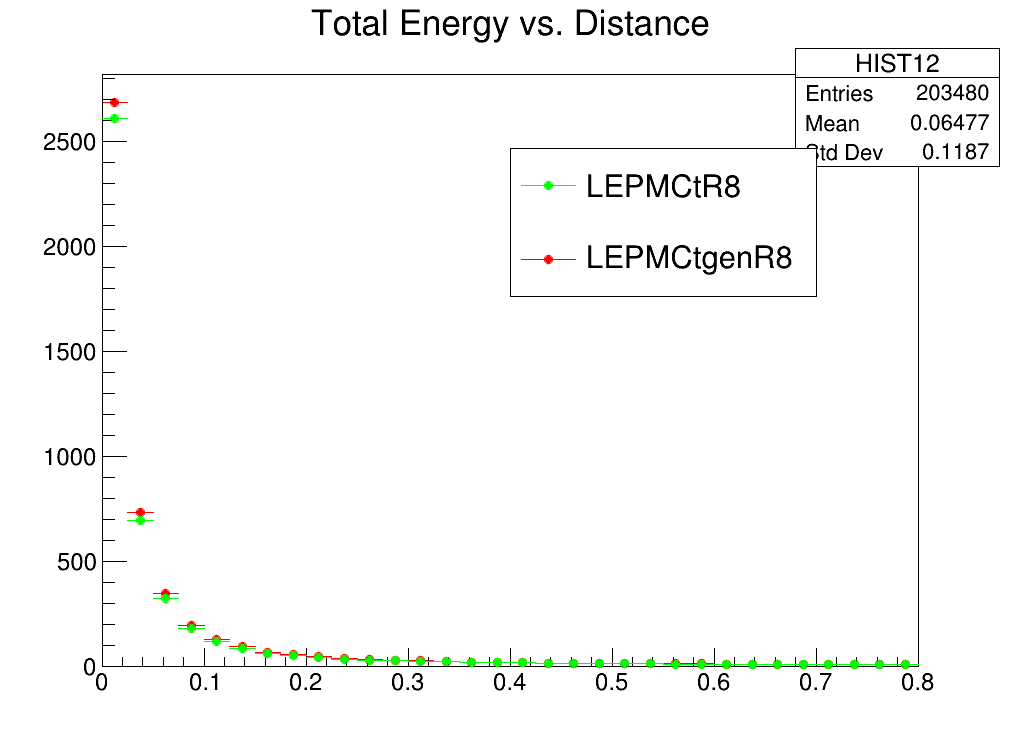

In [17]:
Canvas = ROOT.TCanvas("Canvas", "", 1024, 768)
#Canvas.SetLogy()
#File1 = ROOT.TFile("MCbestdistancetheta.root")
#different simulation matchbox vs. sherpa vs. LEPIMC
#with and without detector effects which is LEPIMC with t and tgen two histograms
#everything under LEPIMC ALEPHMC
# with detector vs. data LEPIMC vs. LEPIData 
File2 = ROOT.TFile("reconLEPMCtgenR8.root")
File3 = ROOT.TFile("reconLEPMCtR8.root")

#Hist1 = File1.Get("HIST12")
Hist2 = File2.Get("HIST12")
Hist3 = File3.Get("HIST12")

#Hist1.SetLineColor(ROOT.kBlue)
Hist2.SetLineColor(ROOT.kRed)
Hist3.SetLineColor(ROOT.kGreen)

Legend = ROOT.TLegend(0.5, 0.8, 0.8, 0.6)
Legend.AddEntry(Hist3, "LEPMCtR8", "lp")
Legend.AddEntry(Hist2, "LEPMCtgenR8", "lp")
#Legend.AddEntry(Hist3, "LEPMCR8", "lp")
#Hist16.projectiony

#Hist1.SetMarkerStyle(20)
#Hist1.SetMarkerColor(ROOT.kBlue)
Hist2.SetMarkerStyle(20)
Hist2.SetMarkerColor(ROOT.kRed)
Hist3.SetMarkerStyle(20)
Hist3.SetMarkerColor(ROOT.kGreen)
#Hist1.Draw("colz");
Hist2.Draw("same")
Hist3.Draw("same")

#Efficiency = eff.GetBinContent(eff.FindBin(pt,theta,Ntrk))
#Do everything with R8 and <0.8 distance 
#
Canvas.Draw()
Legend.Draw()

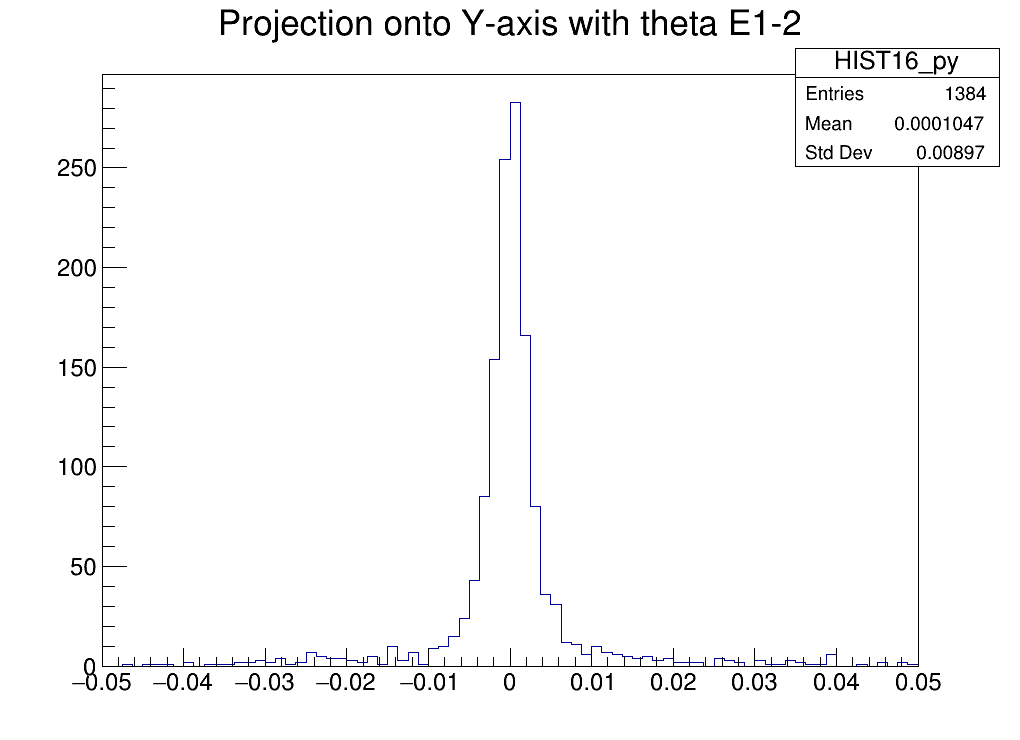

In [10]:
Hist16 = File1.Get("HIST16")
hpy = Hist16.ProjectionY("HIST16_py")
hpy.SetTitle("Projection onto Y-axis with theta E1-2")
hpy.Draw()
Canvas.Draw()


****************************************
Minimizer is Minuit / Migrad
Chi2                      =  2.39952e-07
NDf                       =            1
Edm                       =  8.38364e-07
NCalls                    =           63
p0                        =   0.00697313   +/-   0.00113195  
p1                        =    0.0052992   +/-   0.0137495   
p2                        =   0.00467551   +/-   0.0234649   
x[0]=5.56545e-315, y[0]=5.59086e-315, ex[0]=0, ey[0]=0
x[1]=1.5, y[1]=0.00897, ex[1]=0.5, ey[1]=0.00897
x[2]=2.5, y[2]=0.008121, ex[2]=0.5, ey[2]=0.008121
x[3]=4, y[3]=0.007134, ex[3]=1, ey[3]=0.007134
x[4]=7.5, y[4]=0.007324, ex[4]=2.5, ey[4]=0.007324


Warning in <TCanvas::Constructor>: Deleting canvas with same name: Canvas


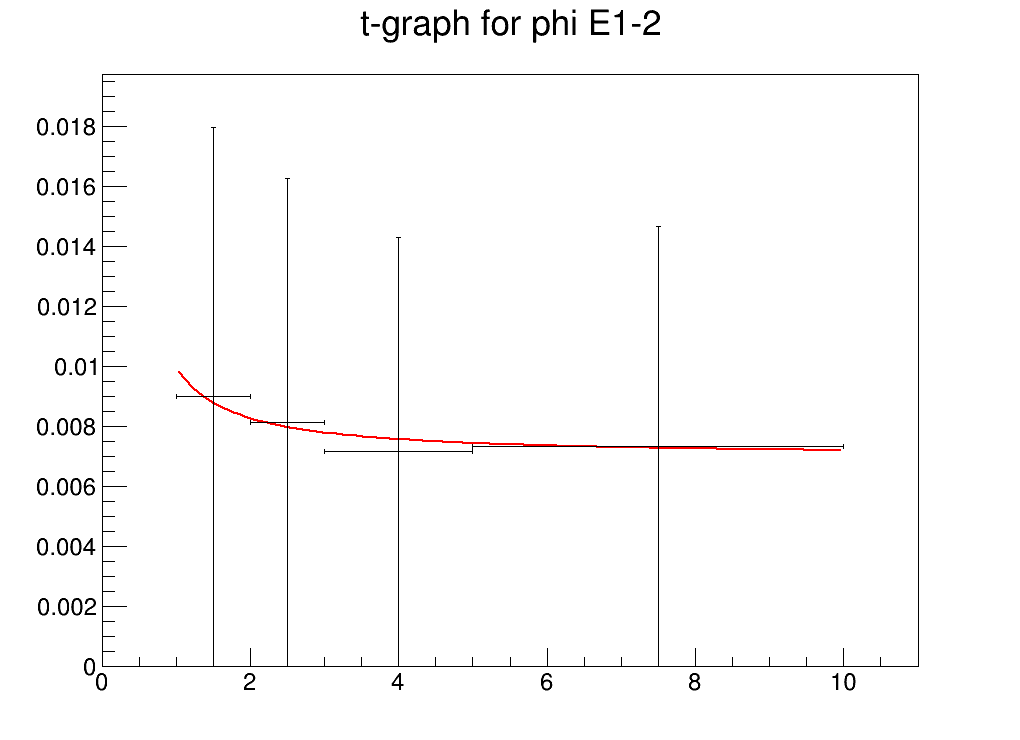

In [14]:
#Line of best fit
#sqrt(aknot**2 
#TF1 Function 
Canvas = ROOT.TCanvas("Canvas", "", 1024, 768)
rft1 = ROOT.TF1("name", "sqrt([0]**2 + ([1]**2 / x) + ([2]**2 / x**2))", 0, 10)
rft1.SetParameters(.01, .01, .01)
graph.Fit(rft1, "SW", "", 1, 10)
graph.SetTitle("t-graph for phi E1-2")
graph.Draw("ap")
Canvas.Draw()
graph.Print()


## graph.SetPoint(2, 2.5, 0.001484)
graph.SetPoint(3, 4, 0.001314)
graph.SetPoint(4, 7.5, 0.001202)